In [1]:
from google.colab import files

uploaded = files.upload()


Saving archive.zip to archive.zip


In [2]:
import zipfile
import os

zip_path = "archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os
import pandas as pd

dataset_path = "/content/dataset/Breast Thermography"

data = []

for label_name, label in [("Benign", 0), ("Malignant", 1)]:

    class_path = os.path.join(dataset_path, label_name)

    for patient_id in os.listdir(class_path):

        patient_path = os.path.join(class_path, patient_id)

        # Make sure it is actually a folder
        if not os.path.isdir(patient_path):
            continue

        for filename in os.listdir(patient_path):

            if filename.lower().endswith((".jpg", ".jpeg", ".png")):

                image_path = os.path.join(
                    patient_path,
                    filename
                )

                # Determine view
                if "anterior" in filename.lower():
                    view = "anterior"

                elif "oblleft" in filename.lower():
                    view = "left"

                elif "oblright" in filename.lower():
                    view = "right"

                else:
                    view = "unknown"

                data.append({
                    "patient_id": patient_id,
                    "image_path": image_path,
                    "view": view,
                    "label": label,
                    "class": label_name
                })

metadata = pd.DataFrame(data)

metadata.to_csv(
    "/content/metadata.csv",
    index=False
)

print("metadata.csv created successfully!")

metadata.csv created successfully!


In [4]:
metadata.head(10)

,patient_id,image_path,view,label,class
0,IIR0088,/content/dataset/Breast Thermography/Benign/II...,left,0,Benign
1,IIR0088,/content/dataset/Breast Thermography/Benign/II...,anterior,0,Benign
2,IIR0088,/content/dataset/Breast Thermography/Benign/II...,right,0,Benign
3,IIR0007,/content/dataset/Breast Thermography/Benign/II...,left,0,Benign
4,IIR0007,/content/dataset/Breast Thermography/Benign/II...,anterior,0,Benign
5,IIR0007,/content/dataset/Breast Thermography/Benign/II...,right,0,Benign
6,IIR0057,/content/dataset/Breast Thermography/Benign/II...,right,0,Benign
7,IIR0057,/content/dataset/Breast Thermography/Benign/II...,left,0,Benign
8,IIR0057,/content/dataset/Breast Thermography/Benign/II...,anterior,0,Benign
9,IIR0011,/content/dataset/Breast Thermography/Benign/II...,right,0,Benign


In [8]:
#Benign tumors are non-cancerous and stay localized, while malignant tumors are cancerous and can spread to other parts of the body.
print("Total images:", len(metadata))
print("Total patients:", metadata["patient_id"].nunique())
print(metadata["class"].value_counts())


Total images: 357
Total patients: 119
class
Benign       252
Malignant    105
Name: count, dtype: int64
class
Benign       84
Malignant    35
dtype: int64


In [10]:
#Benign vs malignant patients
print(
    metadata.groupby(
        ["class", "patient_id"]
    ).size().groupby(level=0).size()
)


class
Benign       84
Malignant    35
dtype: int64


In [12]:
#. Check that every patient has 3 images
images_per_patient = metadata.groupby("patient_id").size()

print(images_per_patient.value_counts())

3    119
Name: count, dtype: int64


In [13]:
print(
    metadata[metadata["view"] == "unknown"]
)

Empty DataFrame
Columns: [patient_id, image_path, view, label, class]
Index: []


In [14]:
from google.colab import files

files.download("/content/metadata.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
#STEP 2

In [16]:
import pandas as pd
import os
from PIL import Image

metadata = pd.read_csv("/content/metadata.csv")

print("Metadata loaded successfully!")
print("Number of images:", len(metadata))
print("Number of patients:", metadata["patient_id"].nunique())

Metadata loaded successfully!
Number of images: 357
Number of patients: 119


In [17]:
#checking for any missing data
missing_files = []

for path in metadata["image_path"]:
    if not os.path.exists(path):
        missing_files.append(path)

print("Missing files:", len(missing_files))

Missing files: 0


In [18]:
#checking dimeesnions of images
dimensions = []

for path in metadata["image_path"]:
    img = Image.open(path)
    dimensions.append(img.size)

metadata["width"] = [d[0] for d in dimensions]
metadata["height"] = [d[1] for d in dimensions]

print(metadata[["width", "height"]].value_counts())#

width  height
320    240       357
Name: count, dtype: int64


In [20]:
corrupted_images = []

for path in metadata["image_path"]:
    try:
        img = Image.open(path)
        img.verify()

    except Exception:
        corrupted_images.append(path)

print("Corrupted images:", len(corrupted_images))

Corrupted images: 0


In [23]:
view_counts = metadata.groupby("patient_id")["view"].nunique()

print(
    "Patients with missing views:",
    (view_counts != 3).sum()
)

Patients with missing views: 0


In [24]:
print("======================================")
print("       DATASET VALIDATION REPORT")
print("======================================")

print("Total images:", len(metadata))
print("Total patients:", metadata["patient_id"].nunique())

print("--------------------------------------")

print("Missing files:", len(missing_files))
print("Corrupted images:", len(corrupted_images))

print("--------------------------------------")

print(
    "Patients without exactly 3 views:",
    (images_per_patient != 3).sum()
)

print(
    "Patients with missing view types:",
    (view_counts != 3).sum()
)

print("======================================")

       DATASET VALIDATION REPORT
Total images: 357
Total patients: 119
--------------------------------------
Missing files: 0
Corrupted images: 0
--------------------------------------
Patients without exactly 3 views: 0
Patients with missing view types: 0


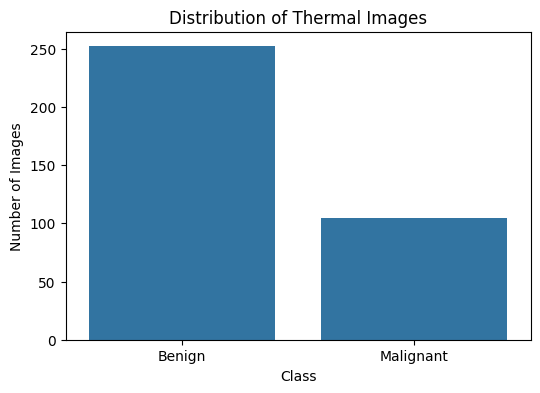

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=metadata, x="class")

plt.title("Distribution of Thermal Images")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [42]:
from PIL import Image
import matplotlib.pyplot as plt

def show_patient(patient_id):

    patient_data = metadata[
        metadata["patient_id"] == patient_id
    ]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    for ax, (_, row) in zip(axes, patient_data.iterrows()):

        img = Image.open(row["image_path"])

        ax.imshow(img)
        ax.set_title(row["view"])
        ax.axis("off")

    plt.suptitle(
        f"Patient: {patient_id} | Class: {patient_data['class'].iloc[0]}"
    )

    plt.show()

In [30]:
print([x for x in globals() if 'dataset' in x.lower()])
print([x for x in globals() if 'loader' in x.lower()])

['dataset_path']
['__loader__']


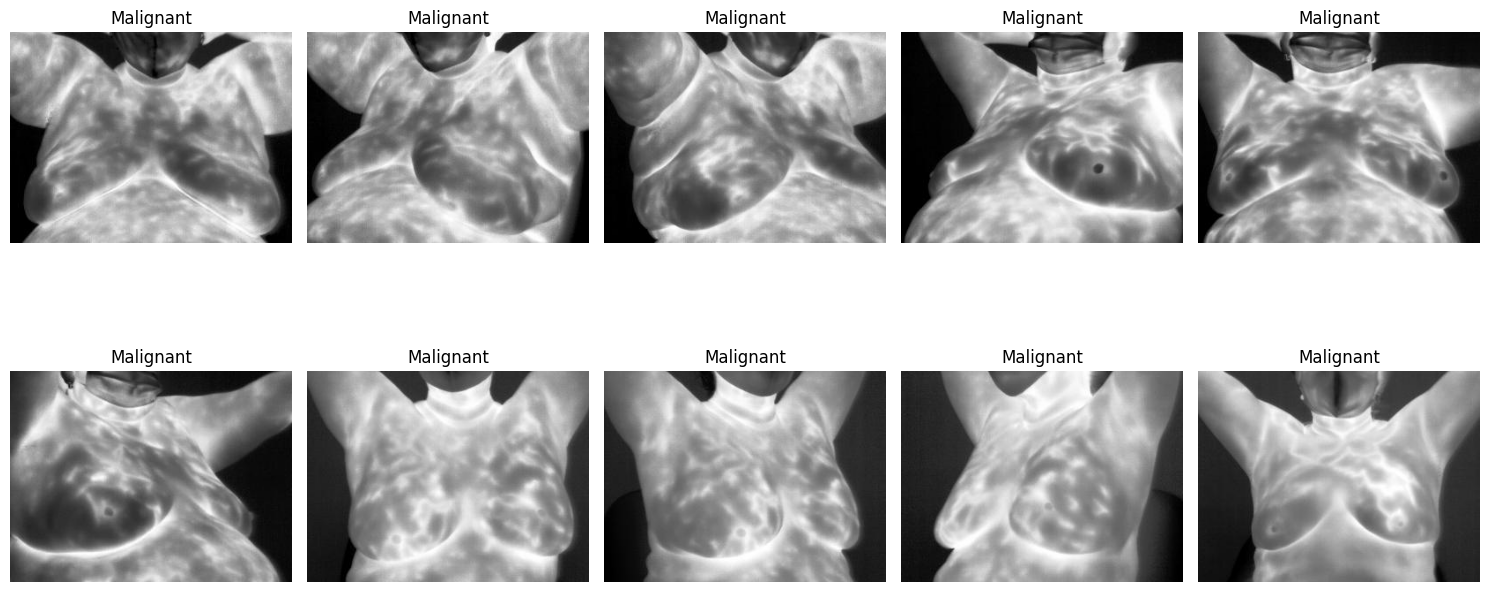

Images displayed: 10


In [34]:
import os
import matplotlib.pyplot as plt
from PIL import Image

classes = ["Malignant", "Benign"]

plt.figure(figsize=(15, 8))

image_count = 0

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    # Go through patient/image folders
    for patient_folder in os.listdir(class_path):

        patient_path = os.path.join(class_path, patient_folder)

        if not os.path.isdir(patient_path):
            continue

        # Find image files inside the patient folder
        for file_name in os.listdir(patient_path):

            file_path = os.path.join(patient_path, file_name)

            try:
                image = Image.open(file_path)

                plt.subplot(2, 5, image_count + 1)
                plt.imshow(image)
                plt.title(class_name)
                plt.axis("off")

                image_count += 1

                if image_count == 10:
                    break

            except:
                continue

        if image_count == 10:
            break

    if image_count == 10:
        break

plt.tight_layout()
plt.show()

print("Images displayed:", image_count)

In [35]:
#CREATING 5 FOLD CV


In [37]:
patients = metadata[
    ["patient_id", "label", "class"]
].drop_duplicates()

print("Total patients:", len(patients))

print("\nClass distribution:")
print(patients["class"].value_counts())

Total patients: 119

Class distribution:
class
Benign       84
Malignant    35
Name: count, dtype: int64


In [43]:
from sklearn.model_selection import StratifiedGroupKFold

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Reset index so positions match
patients = patients.reset_index(drop=True)

patients["fold"] = -1

for fold, (train_idx, val_idx) in enumerate(
    cv.split(
        patients,
        patients["label"],
        groups=patients["patient_id"]
    )
):
    patients.loc[val_idx, "fold"] = fold

print(patients["fold"].value_counts().sort_index())

fold
0    24
1    24
2    24
3    23
4    24
Name: count, dtype: int64


In [44]:
#checking class distribution
print(
    pd.crosstab(
        patients["fold"],
        patients["class"]
    )
)

class  Benign  Malignant
fold                    
0          17          7
1          17          7
2          18          6
3          16          7
4          16          8


In [45]:
#verifying no patient leakage
for fold in range(5):

    validation_patients = set(
        patients[
            patients["fold"] == fold
        ]["patient_id"]
    )

    training_patients = set(
        patients[
            patients["fold"] != fold
        ]["patient_id"]
    )

    overlap = validation_patients.intersection(
        training_patients
    )

    print(
        f"Fold {fold}: Patient overlap = {len(overlap)}"
    )

Fold 0: Patient overlap = 0
Fold 1: Patient overlap = 0
Fold 2: Patient overlap = 0
Fold 3: Patient overlap = 0
Fold 4: Patient overlap = 0


In [46]:
#adding fold information to metadata
metadata = metadata.drop(columns=["fold"], errors="ignore")

metadata = metadata.merge(
    patients[["patient_id", "fold"]],
    on="patient_id",
    how="left"
)

print(metadata.head())

  patient_id                                         image_path      view  \
0    IIR0088  /content/dataset/Breast Thermography/Benign/II...      left   
1    IIR0088  /content/dataset/Breast Thermography/Benign/II...  anterior   
2    IIR0088  /content/dataset/Breast Thermography/Benign/II...     right   
3    IIR0007  /content/dataset/Breast Thermography/Benign/II...      left   
4    IIR0007  /content/dataset/Breast Thermography/Benign/II...  anterior   

   label   class  width  height  fold  
0      0  Benign    320     240     3  
1      0  Benign    320     240     3  
2      0  Benign    320     240     3  
3      0  Benign    320     240     0  
4      0  Benign    320     240     0  


In [47]:
#saving the split
metadata.to_csv(
    "/content/metadata_with_folds.csv",
    index=False
)

patients.to_csv(
    "/content/patient_folds.csv",
    index=False
)

print("Patient-level folds saved successfully!")

Patient-level folds saved successfully!


In [49]:
dataset_path_1 = "/content/metadata_with_folds.csv"
dataset_path_2 = "/content/patient_folds.csv"

metadata_with_folds = pd.read_csv(dataset_path_1)
patients_folds = pd.read_csv(dataset_path_2)

In [50]:
print(metadata.columns)
print(metadata_with_folds.columns)
print(patients_folds.columns)

Index(['patient_id', 'image_path', 'view', 'label', 'class', 'width', 'height',
       'fold'],
      dtype='object')
Index(['patient_id', 'image_path', 'view', 'label', 'class', 'width', 'height',
       'fold'],
      dtype='object')
Index(['patient_id', 'label', 'class', 'fold'], dtype='object')
